# Traffic Sign Classification Using CNN with TensorFlow and Bayesian Optimization

## Importing Required Libraries

In [1]:
import os
import csv
import cv2
import random
import pathlib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_tuner as kt
from PIL import Image
from tqdm import tqdm
from tensorflow import keras
from matplotlib.image import imread
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Conv2D, MaxPool2D, BatchNormalization, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow.keras.optimizers import Adam
from keras.models import Sequential

np.random.seed(42) # Set random seed for reproducibility

In [2]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.10.1


In [3]:
# Check if GPU is available
print("GPU is", "available" if tf.config.list_physical_devices('GPU') else "NOT available")

# Check which GPU is being used (if available)
if tf.config.list_physical_devices('GPU'):
    print("GPU device:", tf.test.gpu_device_name())

GPU is available
GPU device: /device:GPU:0


## Data Preparation and Exploration

### Assigning Path for Dataset

In [ ]:
data_dir = '../../data/Classification'
train_path = '../../data/Classification/Train'
test_path = '../../data/Classification/Test'

# Resizing the images to 50x50x3
IMG_HEIGHT = 50
IMG_WIDTH = 50
channels = 3

### Finding Total Classes

In [5]:
NUM_CATEGORIES = len(os.listdir(train_path))
NUM_CATEGORIES

15

### Set Labels

In [6]:
# Read the CSV file
labels_df = pd.read_csv(data_dir + '/tsc_labels.csv')

# Convert the DataFrame to a dictionary
classes = pd.Series(labels_df.Name.values,index=labels_df.ClassId).to_dict()

### Visualizing the Dataset

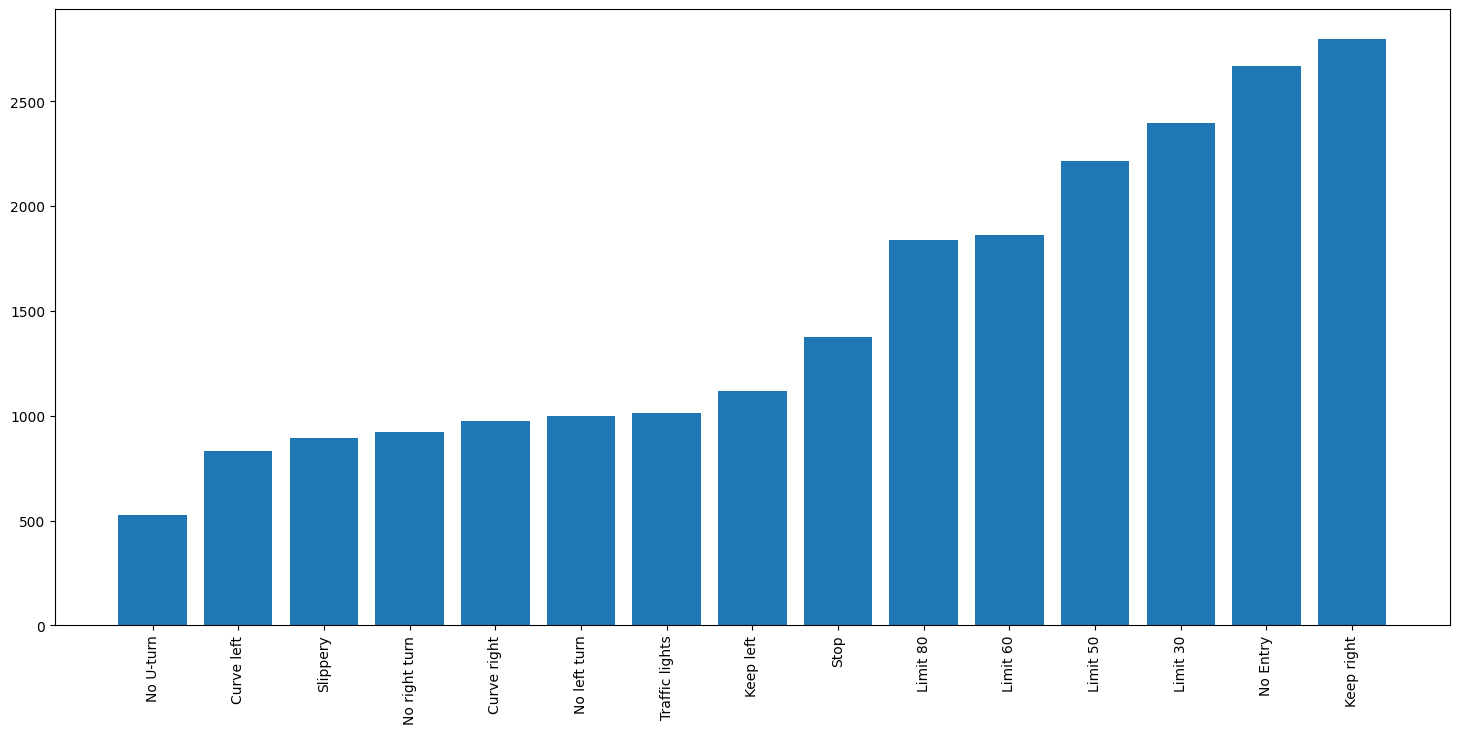

In [7]:
folders = os.listdir(train_path)

train_number = []
class_num = []

for folder in folders:
    train_files = os.listdir(train_path + '/' + folder)
    train_number.append(len(train_files))
    class_num.append(classes[int(folder)])
    
# Sorting the dataset on the basis of number of images in each class
zipped_lists = zip(train_number, class_num)
sorted_pairs = sorted(zipped_lists)
tuples = zip(*sorted_pairs)
train_number, class_num = [ list(tuple) for tuple in  tuples]

# Plotting the number of images in each class
plt.figure(figsize=(18,8))  
plt.bar(class_num, train_number)
plt.xticks(class_num, rotation='vertical')
plt.show()

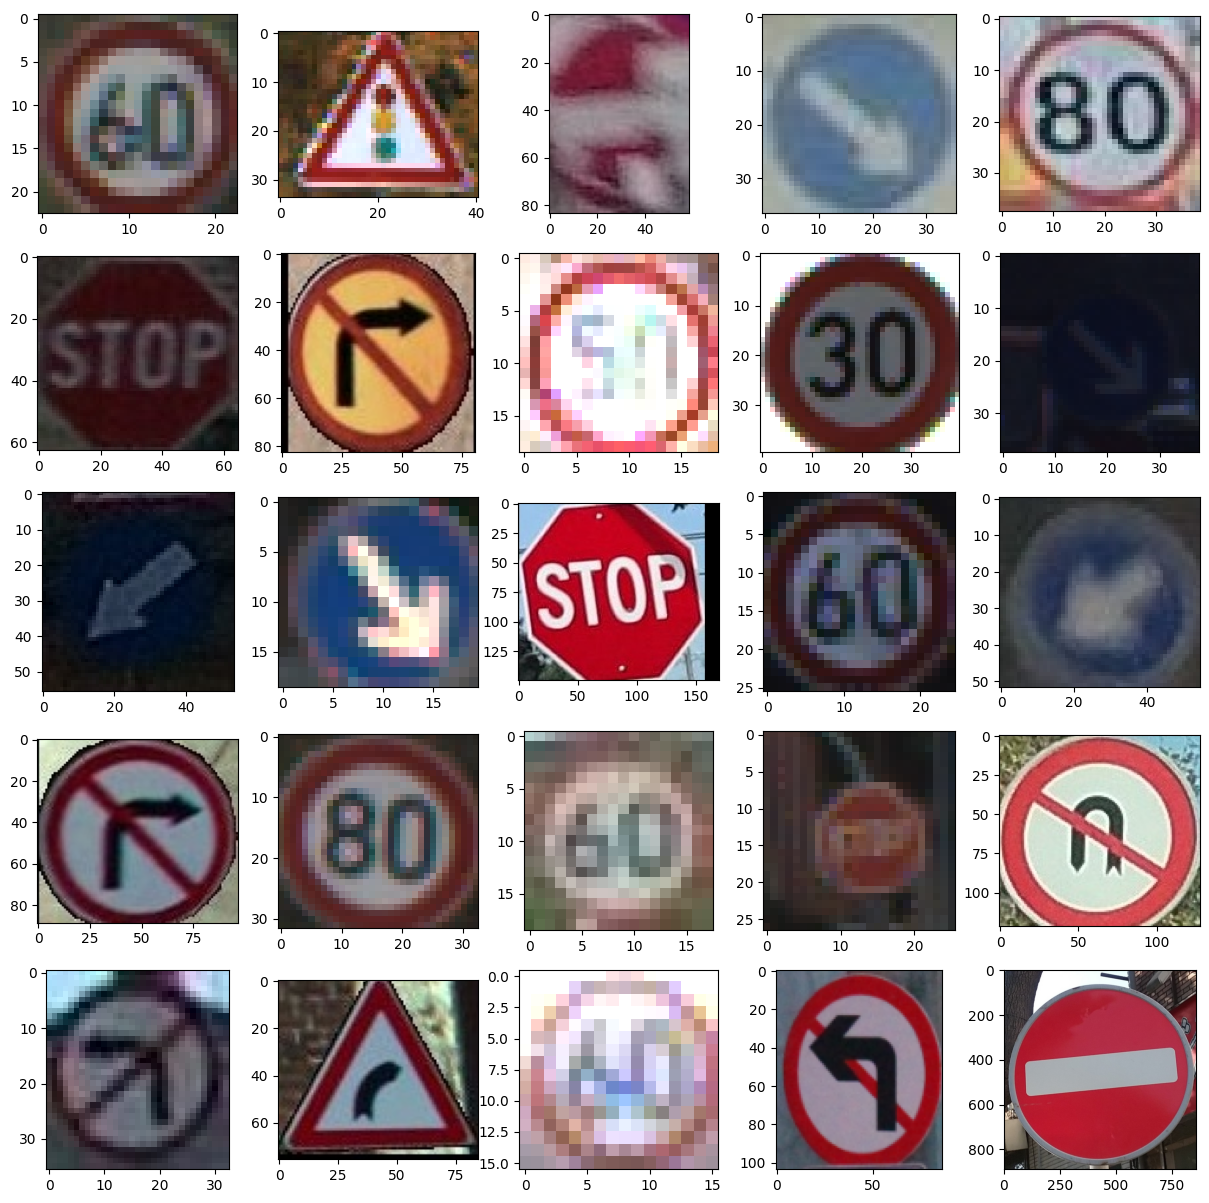

In [8]:
# Visualizing 25 random images from test data
test = pd.read_csv(data_dir + '/test_labels.csv')
imgs = test["Path"].values

plt.figure(figsize=(15,15))

for i in range(1,26):
    plt.subplot(5,5,i)
    random_img_path = data_dir + '/' + random.choice(imgs)
    rand_img = imread(random_img_path)
    plt.imshow(rand_img)
    plt.grid(visible=False)

### Collecting the Training Data

In [9]:
# Load images and labels from the training set
image_data = []
image_labels = []

for i in tqdm(range(NUM_CATEGORIES), desc="Loading images"):
    path = data_dir + '/Train/' + str(i)
    images = os.listdir(path)

    for img in tqdm(images, desc=f"Loading category {i}", leave=False):
        try:
            image = cv2.imread(path + '/' + img)
            image_fromarray = Image.fromarray(image, 'RGB')
            resize_image = image_fromarray.resize((IMG_HEIGHT, IMG_WIDTH))
            image_data.append(np.array(resize_image))
            image_labels.append(i)
        except:
            print("Error in " + img)

# Convert the lists to numpy arrays
image_data = np.array(image_data)
image_labels = np.array(image_labels)

print(image_data.shape, image_labels.shape)

Loading images: 100%|██████████| 15/15 [00:16<00:00,  1.11s/it]

(22438, 50, 50, 3) (22438,)


## Data Preprocessing

### Shuffling the Training Data

In [10]:
shuffle_indexes = np.arange(image_data.shape[0])
np.random.shuffle(shuffle_indexes)
image_data = image_data[shuffle_indexes]
image_labels = image_labels[shuffle_indexes]

### Splitting the Data Into Train and Validation Set

In [11]:
X_train, X_val, y_train, y_val = train_test_split(image_data, image_labels, test_size=0.2, random_state=42, shuffle=True)

print("X_train.shape", X_train.shape)
print("X_valid.shape", X_val.shape)
print("y_train.shape", y_train.shape)
print("y_valid.shape", y_val.shape)

X_train.shape (17950, 50, 50, 3)
X_valid.shape (4488, 50, 50, 3)
y_train.shape (17950,)
y_valid.shape (4488,)


### Data Normalization

In [12]:
X_train = X_train/255 
X_val = X_val/255

### One-Hot Encoding the Labels

In [13]:
y_train = keras.utils.to_categorical(y_train, NUM_CATEGORIES)
y_val = keras.utils.to_categorical(y_val, NUM_CATEGORIES)

print(y_train.shape)
print(y_val.shape)

(17950, 15)
(4488, 15)


### Data Augmentation

In [14]:
aug = ImageDataGenerator(
    rotation_range=1,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=False,
    vertical_flip=False,
    fill_mode="nearest")

## Hyperparameter Tuning

### Define the Model Builder Function for Keras Tuner

In [15]:
def build_model(hp):
    model = Sequential([
        Conv2D(
            filters=hp.Choice('filters_1', values=[8, 16]),
            kernel_size=(3,3), activation='relu',
            input_shape=(IMG_HEIGHT, IMG_WIDTH, channels)
        ),
        Conv2D(
            filters=hp.Choice('filters_2', values=[16, 32]),
            kernel_size=(3,3), activation='relu'
        ),
        MaxPool2D(pool_size=(2, 2)),
        BatchNormalization(axis=-1),
        Conv2D(
            filters=hp.Choice('filters_3', values=[32, 64]),
            kernel_size=(3,3), activation='relu'
        ),
        keras.layers.Conv2D(
            filters=hp.Choice('filters_4', values=[64, 128]),
            kernel_size=(3,3), activation='relu'
        ),
        MaxPool2D(pool_size=(2, 2)),
        BatchNormalization(axis=-1),
        Flatten(),
        Dense(units=hp.Choice('dense_units', values=[256, 512]), activation='relu'),
        BatchNormalization(),
        Dropout(rate=hp.Choice('dropout', values=[0.3, 0.5])),
        Dense(NUM_CATEGORIES, activation='softmax')
    ])
    
    learning_rate = hp.Choice('learning_rate', values=[0.01, 0.001])
    optimizer = Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

### Set up Keras Tuner

In [16]:
# Define the BayesianOptimization tuner
tuner = kt.BayesianOptimization(
    build_model,
    objective='val_accuracy',
    max_trials=50,
    directory='bayesian_optim',
    project_name='tsc'
)

# Define EarlyStopping callback
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

### Perform Hyperparameter Search

In [17]:
# Start hyperparameter tuning
tuner.search(aug.flow(X_train, y_train, batch_size=16), validation_data=(X_val, y_val), epochs=30, callbacks=[early_stopping])

Trial 50 Complete [00h 08m 59s]
val_accuracy: 0.9971033930778503

Best val_accuracy So Far: 0.9973261952400208
Total elapsed time: 04h 59m 06s


### Save All Hyperparameters and Results to CSV

In [18]:
# Retrieve all trial results
trials = tuner.oracle.trials.values()

# Prepare a list to store all trial data
trials_data = []

# Collect data from each trial
for trial in trials:
    if trial.status == 'COMPLETED':  # Check if the trial was completed successfully
        trial_data = trial.hyperparameters.values.copy()
        trial_data['score'] = trial.score
        trials_data.append(trial_data)

# Sort the trials_data list based on the 'score' in descending order
trials_data = sorted(trials_data, key=lambda x: x['score'], reverse=True)

# Dynamically collect all field names for creating a CSV header
field_names = set()
for data in trials_data:
    field_names.update(data.keys())

field_names = list(field_names)

# Define the CSV file path
csv_file_path = 'hyparam_results_bo.csv'

# Write to CSV
with open(csv_file_path, mode='w', newline='') as file:
    writer = csv.DictWriter(file, fieldnames=field_names)
    writer.writeheader()
    writer.writerows(trials_data)

print(f"Hyperparameters and results have been saved to {csv_file_path}")

Hyperparameters and results have been saved to hyparam_results_bo.csv


## Model Training

### Training the Model with the Best Hyperparameters

In [19]:
# Retrieve the best hyperparameters
best_hps = tuner.get_best_hyperparameters()[0]

# Build the model using the best hyperparameters
model_tuned = tuner.hypermodel.build(best_hps)

# Display the model
model_tuned.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 48, 48, 16)        448       
                                                                 
 conv2d_5 (Conv2D)           (None, 46, 46, 32)        4640      
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 23, 23, 32)       0         
 2D)                                                             
                                                                 
 batch_normalization_3 (Batc  (None, 23, 23, 32)       128       
 hNormalization)                                                 
                                                                 
 conv2d_6 (Conv2D)           (None, 21, 21, 64)        18496     
                                                                 
 conv2d_7 (Conv2D)           (None, 19, 19, 128)      

In [20]:
# Continue with training using model_tuned
history = model_tuned.fit(aug.flow(X_train, y_train, batch_size=16), epochs=30, validation_data=(X_val, y_val), callbacks=[early_stopping])

Epoch 1/30
1122/1122 [==============================] - 20s 17ms/step - loss: 0.6437 - accuracy: 0.8037 - val_loss: 0.1330 - val_accuracy: 0.9563
Epoch 2/30
1122/1122 [==============================] - 18s 16ms/step - loss: 0.1947 - accuracy: 0.9365 - val_loss: 0.0558 - val_accuracy: 0.9826
Epoch 3/30
1122/1122 [==============================] - 18s 16ms/step - loss: 0.1377 - accuracy: 0.9569 - val_loss: 0.0812 - val_accuracy: 0.9793
Epoch 4/30
1122/1122 [==============================] - 18s 16ms/step - loss: 0.1280 - accuracy: 0.9604 - val_loss: 0.0584 - val_accuracy: 0.9804
Epoch 5/30
1122/1122 [==============================] - 18s 16ms/step - loss: 0.1038 - accuracy: 0.9680 - val_loss: 0.0737 - val_accuracy: 0.9719
Epoch 6/30
1122/1122 [==============================] - 17s 16ms/step - loss: 0.0824 - accuracy: 0.9738 - val_loss: 0.0206 - val_accuracy: 0.9935
Epoch 7/30
1122/1122 [==============================] - 18s 16ms/step - loss: 0.0685 - accuracy: 0.9793 - val_loss: 0.0204 -

## Evaluating the Model

### Visualizing the Training Graphs

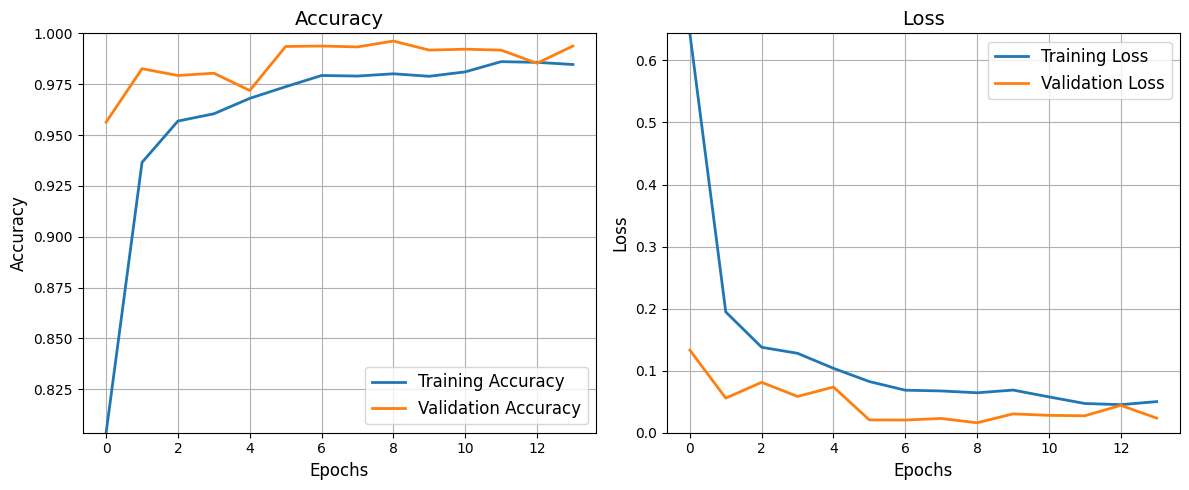

In [21]:
history_df = pd.DataFrame(history.history)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot accuracy
ax1.plot(history_df.index, history_df['accuracy'], label='Training Accuracy', linewidth=2)
ax1.plot(history_df.index, history_df['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.set_title('Accuracy', fontsize=14)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_ylim(history_df[['accuracy', 'val_accuracy']].min().min(), 1)
ax1.grid(True)
ax1.legend(fontsize=12)

# Plot loss
ax2.plot(history_df.index, history_df['loss'], label='Training Loss', linewidth=2)
ax2.plot(history_df.index, history_df['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_title('Loss', fontsize=14)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_ylim(0, history_df[['loss', 'val_loss']].max().max())
ax2.grid(True)
ax2.legend(fontsize=12)

plt.tight_layout()
plt.show()

### Loading the Test Data and Running the Predictions

In [22]:
test = pd.read_csv(data_dir + '/test_labels.csv')

labels = test["ClassId"].values
imgs = test["Path"].values

data = []

for img in imgs:
    try:
        image = cv2.imread(data_dir + '/' +img)
        image_fromarray = Image.fromarray(image, 'RGB')
        resize_image = image_fromarray.resize((IMG_HEIGHT, IMG_WIDTH))
        data.append(np.array(resize_image))
    except:
        print("Error in " + img)

X_test = np.array(data)
X_test = X_test / 255

# Predict probabilities
pred_probabilities = model_tuned.predict(X_test)

# Convert probabilities into class labels
pred = np.argmax(pred_probabilities, axis=-1)

# Accuracy with the test data
print('Test Data accuracy: ', accuracy_score(labels, pred)*100)

176/176 [==============================] - 1s 5ms/step
Test Data accuracy:  99.58957887223411


### Visualizing the Confusion Matrix

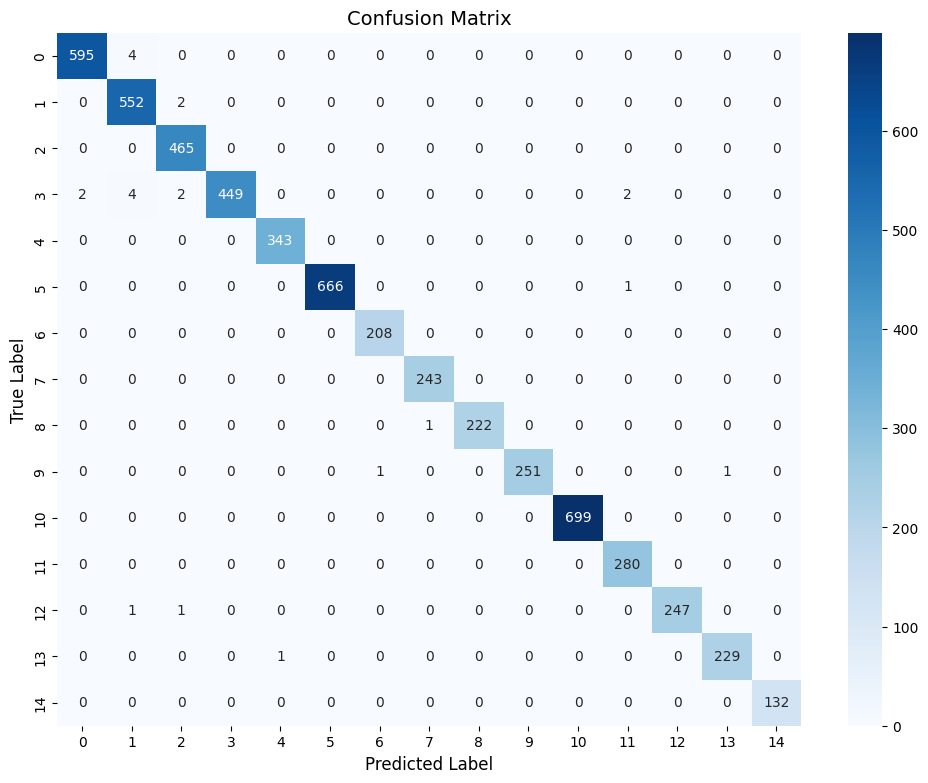

In [23]:
conf = confusion_matrix(labels, pred)

plt.figure(figsize=(12, 9))
sns.heatmap(conf, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
plt.show()

### Classification Report

In [24]:
print(classification_report(labels, pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       599
           1       0.98      1.00      0.99       554
           2       0.99      1.00      0.99       465
           3       1.00      0.98      0.99       459
           4       1.00      1.00      1.00       343
           5       1.00      1.00      1.00       667
           6       1.00      1.00      1.00       208
           7       1.00      1.00      1.00       243
           8       1.00      1.00      1.00       223
           9       1.00      0.99      1.00       253
          10       1.00      1.00      1.00       699
          11       0.99      1.00      0.99       280
          12       1.00      0.99      1.00       249
          13       1.00      1.00      1.00       230
          14       1.00      1.00      1.00       132

    accuracy                           1.00      5604
   macro avg       1.00      1.00      1.00      5604
weighted avg       1.00   

### Predictions on Test Data

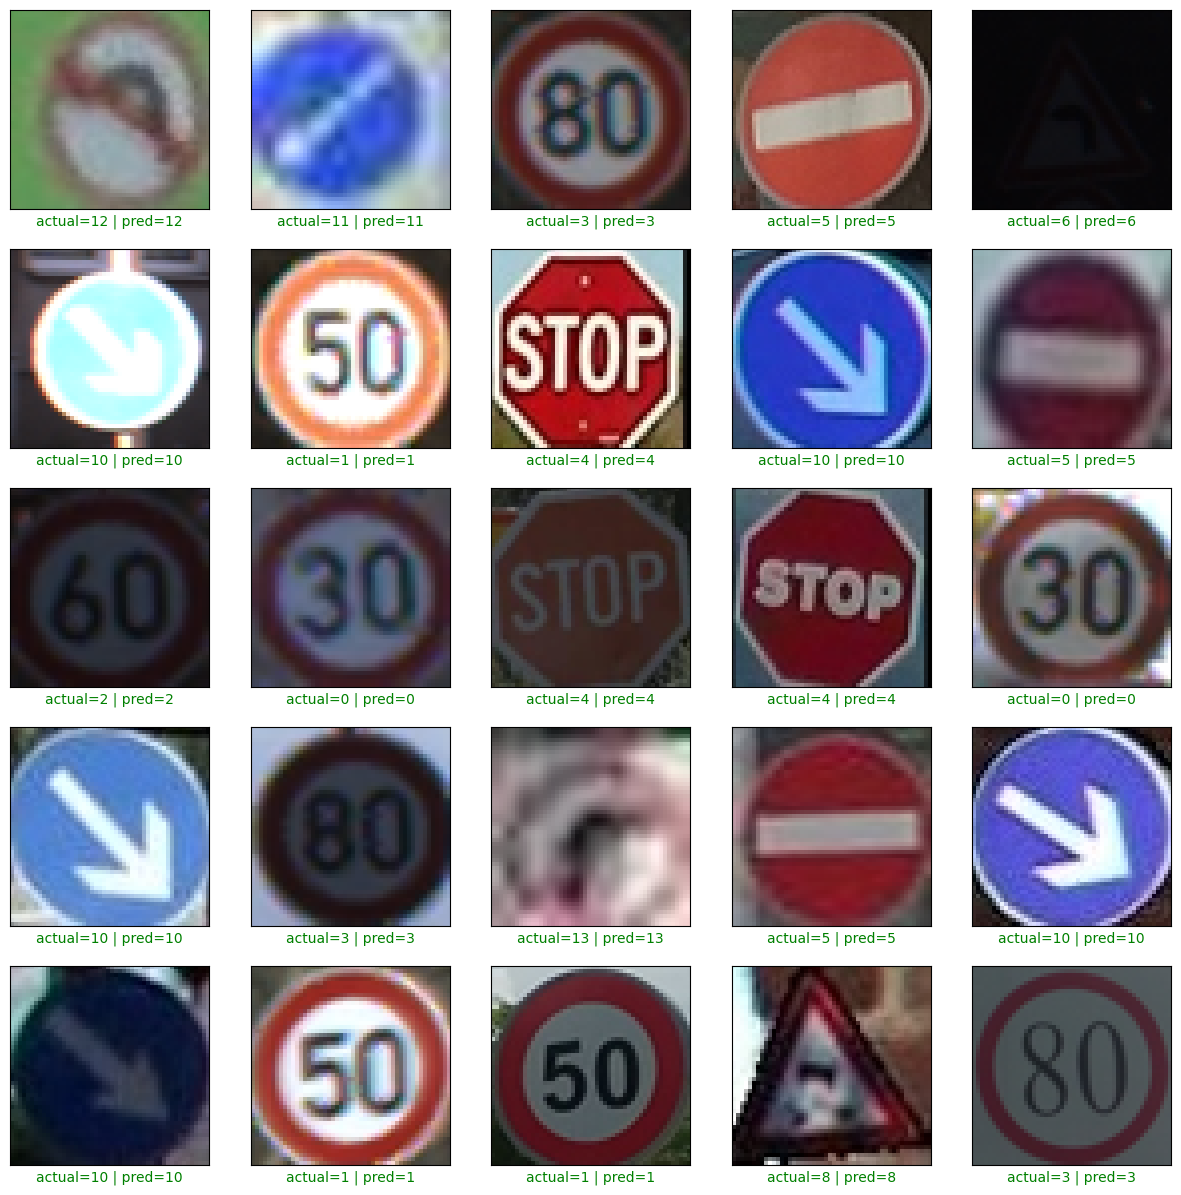

In [25]:
plt.figure(figsize=(15, 15))

# Randomly select 25 unique indices from the range of your dataset's length
random_indices = np.random.choice(len(X_test), 25, replace=False)

for i, index in enumerate(random_indices):
    plt.subplot(5, 5, i + 1)
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    prediction = pred[index]
    actual = labels[index]
    col = 'g' if prediction == actual else 'r'
    plt.xlabel(f'actual={actual} | pred={prediction}', color=col)
    plt.imshow(X_test[index][..., ::-1])

plt.show()

## Export the Model

In [30]:
tf.saved_model.save(model_tuned, "models/tsc-bo_saved_model")

INFO:tensorflow:Assets written to: models/tsc-bo_saved_model\assets


INFO:tensorflow:Assets written to: models/tsc-bo_saved_model\assets


In [31]:
loaded = tf.saved_model.load("models/tsc-bo_saved_model")

In [32]:
print(list(loaded.signatures.keys()))
infer = loaded.signatures["serving_default"]
print(infer.structured_input_signature)
print(infer.structured_outputs)

['serving_default']
((), {'conv2d_4_input': TensorSpec(shape=(None, 50, 50, 3), dtype=tf.float32, name='conv2d_4_input')})
{'dense_3': TensorSpec(shape=(None, 15), dtype=tf.float32, name='dense_3')}


### Convert the SavedModel to TFLite Without Optimizations

In [33]:
saved_model_dir = "models/tsc-bo_saved_model"
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)

# Convert model to TFLite without applying any optimizations
tflite_model = converter.convert()

# Save the TensorFlow Lite model to disk
tflite_model_file = pathlib.Path('models/tsc-bo.tflite')
tflite_model_file.write_bytes(tflite_model)

11030312

### Post-Training Integer Quantization

In [34]:
# Enable default optimizations for quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert X_test to a tf.data.Dataset
X_test_dataset = tf.data.Dataset.from_tensor_slices((X_test, labels))

# Define representative data generator
def representative_data_gen(samples_per_class=150):
    for class_id in range(15):
        class_samples = X_test_dataset.filter(lambda x, y: y == class_id).shuffle(1000).take(samples_per_class)
        for input_value, _ in class_samples:
            yield [np.expand_dims(input_value.numpy().astype(np.float32), axis=0)]

# Assign representative dataset for model calibration
converter.representative_dataset = lambda: representative_data_gen()

# Set model to use integer operations
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

# Set input and output types to int8 for quantization
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# Convert the model to a quantized TFLite format
tflite_quantized_model = converter.convert()

# Save the quantized TFLite model to disk
tflite_quantized_model_file = pathlib.Path('models/tsc-bo_quant.tflite')
tflite_quantized_model_file.write_bytes(tflite_quantized_model)

2770368